In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
from sklearn.feature_selection import mutual_info_classif


# I) DESCRIPTIF DE LA BASE ET MISE EN AVANT DU DESEQUILIBRE DES CLASSES

In [32]:
df = pd.read_csv("loan_applications.csv")
df['fraud_flag'] = df['fraud_flag'].astype(bool) #on va convertir directement la colonne en booléen
                                                 #(parce que ça m'a fatigué quelque part lb)
print("Aperçu des 5 premières lignes :")
display(df.head())

print("\nInformations générales :")
df.info()

print("\nPourcentage de valeurs manquantes par variable :")
missing = df.isnull().mean().sort_values(ascending=False) * 100
display(missing)


Aperçu des 5 premières lignes :


,application_id,customer_id,application_date,loan_type,loan_amount_requested,loan_tenure_months,interest_rate_offered,purpose_of_loan,employment_status,monthly_income,...,existing_emis_monthly,debt_to_income_ratio,property_ownership_status,residential_address,applicant_age,gender,number_of_dependents,loan_status,fraud_flag,fraud_type
0,c8bf0bea-70e6-4870-9125-41b8210c527f,CUST109427,2023-04-09,Business Loan,604000.0,12,11.66,Medical Emergency,Retired,34700.0,...,1100.0,3.17,Rented,"94/31, Sehgal Zila, Vadodara-380521, Anantapur...",28,Female,3,Approved,False,NaN
1,91224cec-3544-4bc7-ac15-a9792da54c02,CUST106146,2023-09-23,Car Loan,100000.0,240,13.62,Education,Unemployed,51600.0,...,0.0,0.00,Owned,"H.No. 00, Sheth Chowk, Ichalkaranji 006728, Im...",44,Other,3,Approved,False,NaN
2,4efcd02d-4a03-4ab7-9bd1-0ff430493d0c,CUST100674,2023-05-22,Education Loan,431000.0,60,11.40,Medical Emergency,Self-Employed,14800.0,...,4600.0,31.08,Rented,"H.No. 81, Dutta Path, Kozhikode-340301, Tadepa...",56,Other,4,Approved,False,NaN
3,a61337d4-ba04-4a68-b492-2cb8266e6ed7,CUST106466,2024-07-09,Car Loan,324000.0,120,10.36,Debt Consolidation,Self-Employed,28800.0,...,4000.0,13.89,Rented,"H.No. 022, Rege Road, Tiruvottiyur-927857, Aur...",27,Other,4,Declined,False,NaN
4,a8d1639e-170b-41b2-826a-55c7dae38d16,CUST112319,2023-11-20,Personal Loan,100000.0,36,14.14,Business Expansion,Salaried,43900.0,...,1100.0,2.51,Rented,"85/24, Bali Zila, Sambalpur 922071, Tumkur, Ke...",50,Other,0,Declined,False,NaN



Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   application_id             50000 non-null  object 
 1   customer_id                50000 non-null  object 
 2   application_date           50000 non-null  object 
 3   loan_type                  50000 non-null  object 
 4   loan_amount_requested      50000 non-null  float64
 5   loan_tenure_months         50000 non-null  int64  
 6   interest_rate_offered      50000 non-null  float64
 7   purpose_of_loan            50000 non-null  object 
 8   employment_status          50000 non-null  object 
 9   monthly_income             50000 non-null  float64
 10  cibil_score                50000 non-null  int64  
 11  existing_emis_monthly      50000 non-null  float64
 12  debt_to_income_ratio       50000 non-null  float64
 13  property_ownership_s

fraud_type                   97.948
existing_emis_monthly         0.000
fraud_flag                    0.000
loan_status                   0.000
number_of_dependents          0.000
gender                        0.000
applicant_age                 0.000
residential_address           0.000
property_ownership_status     0.000
debt_to_income_ratio          0.000
application_id                0.000
customer_id                   0.000
monthly_income                0.000
employment_status             0.000
purpose_of_loan               0.000
interest_rate_offered         0.000
loan_tenure_months            0.000
loan_amount_requested         0.000
loan_type                     0.000
application_date              0.000
cibil_score                   0.000
dtype: float64

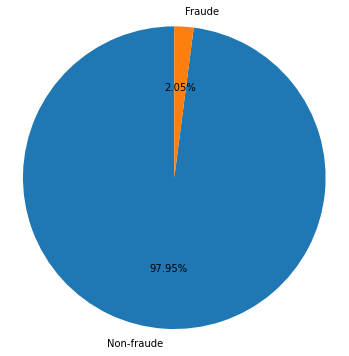

In [5]:
import matplotlib.pyplot as plt

# Comptage des classes
counts = df['fraud_flag'].value_counts()

# Labels
labels = ['Non-fraude', 'Fraude']

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90
)

plt.axis('equal')  # pour un cercle parfait
plt.show()

# II) EFFET DE SWAMPING ET ETUDE DE LA MUTUAL INDEPENDANCE (MI)

In [42]:
num_vars = [
    'loan_amount_requested',
    'monthly_income',
    'debt_to_income_ratio',
    'loan_tenure_months',
    'applicant_age',
    'cibil_score'
]

cat_var = 'purpose_of_loan'
target = 'fraud_flag'


In [43]:
df[target] = df[target].astype(int)


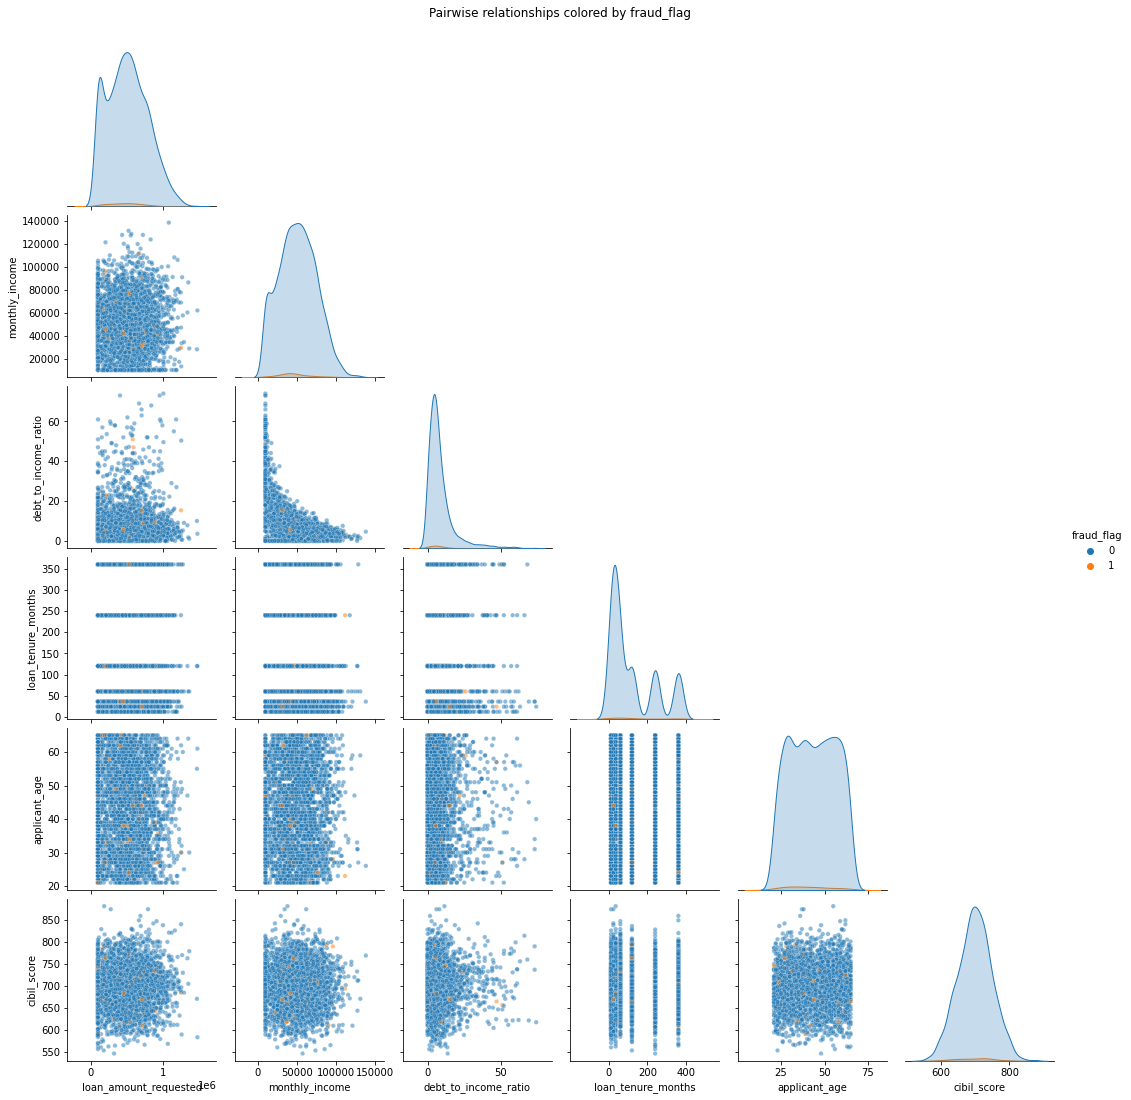

In [44]:
df_sample = df.sample(3000, random_state=42)

sns.pairplot(
    df_sample,
    vars=num_vars,
    hue=target,
    corner=True,
    plot_kws={'alpha': 0.5, 's': 20}
)

plt.suptitle("Pairwise relationships colored by fraud_flag", y=1.02)
plt.show()


In [34]:
df['loan_to_income_ratio'] = (
    df['loan_amount_requested'] / df['monthly_income']
)


In [47]:
X_num = df[num_vars]
y = df[target]

mi_scores = mutual_info_classif(X_num, y, random_state=42)

mi_df = pd.DataFrame({
    'variable': num_vars,
    'MI': mi_scores
}).sort_values('MI', ascending=False)

print(mi_df)


                variable        MI
1         monthly_income  0.018243
3     loan_tenure_months  0.001174
0  loan_amount_requested  0.000983
4          applicant_age  0.000914
5            cibil_score  0.000650
2   debt_to_income_ratio  0.000219


In [37]:
X_ratio = df[['loan_to_income_ratio']]
mi_ratio = mutual_info_classif(X_ratio, y, discrete_features=False)

print("MI loan/income ratio:", mi_ratio[0])


MI loan/income ratio: 0


In [39]:
from sklearn.feature_selection import mutual_info_classif

X_pair = df[['loan_amount_requested', 'monthly_income', 'cibil_score']]
y = df['fraud_flag']

mi_pair = mutual_info_classif(X_pair, y, discrete_features=False)
print(mi_pair)


[0.00029827 0.01744236 0.00050601]


In [40]:
df['complex_interaction'] = (
    df['loan_amount_requested']
    * df['debt_to_income_ratio']
    / df['cibil_score']
)

X_inter = df[['complex_interaction']]
mi_inter = mutual_info_classif(X_inter, y, discrete_features=False)
print(mi_inter)


[0]


Les mesures d’information mutuelle entre les variables prises individuellement (montant du prêt, revenu mensuel) ou sous forme de ratios simples et la variable de fraude restent très faibles.
Ce résultat suggère que la fraude ne dépend pas directement d’une seule variable ou d’une relation bivariée simple, mais probablement de combinaisons plus complexes de variables, ce qui est cohérent avec une dépendance conditionnelle de plus haut ordre.

In [48]:
purpose_dummies = pd.get_dummies(df[cat_var], drop_first=True)


In [49]:
mi_purpose = mutual_info_classif(
    purpose_dummies,
    y,
    random_state=42
)

mi_purpose_df = pd.DataFrame({
    'purpose': purpose_dummies.columns,
    'MI': mi_purpose
}).sort_values('MI', ascending=False)

print(mi_purpose_df)


              purpose        MI
2     Home Renovation  0.001250
1           Education  0.001119
0  Debt Consolidation  0.001074
3   Medical Emergency  0.000974
5             Wedding  0.000486
4    Vehicle Purchase  0.000000


In [50]:
from sklearn.feature_selection import mutual_info_classif

mi_conditional = []

for purpose in df[cat_var].unique():
    df_p = df[df[cat_var] == purpose]
    
    if df_p[target].sum() < 10:
        continue  # pas assez de fraudes
    
    mi_vals = mutual_info_classif(
        df_p[num_vars],
        df_p[target],
        random_state=42
    )
    
    for var, mi in zip(num_vars, mi_vals):
        mi_conditional.append({
            'purpose': purpose,
            'variable': var,
            'MI': mi
        })

mi_cond_df = pd.DataFrame(mi_conditional)


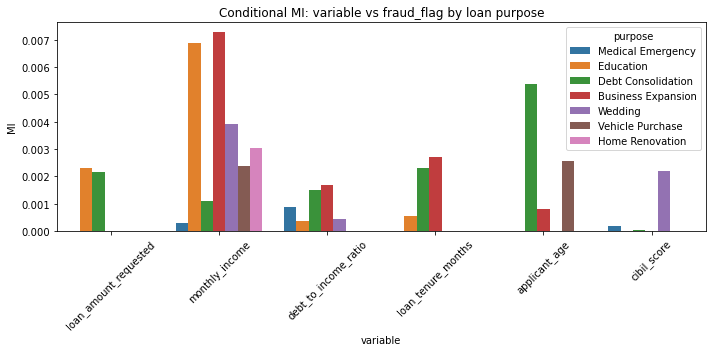

In [51]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=mi_cond_df,
    x='variable',
    y='MI',
    hue='purpose'
)
plt.xticks(rotation=45)
plt.title("Conditional MI: variable vs fraud_flag by loan purpose")
plt.tight_layout()
plt.show()


Les écarts de taux de fraude entre types de prêts soulignent l’importance du contexte transactionnel et renforcent l’existence de dépendances conditionnelles.

# III) TEST GLM ET RAPPORT DE VRAISEMBLANCE (LR)

In [52]:
# Création des dummies pour purpose_of_loan
purpose_dummies = pd.get_dummies(
    df['purpose_of_loan'],
    prefix='purpose',
    drop_first=True   # retire la catégorie de référence
)


In [53]:
import statsmodels.api as sm

# Variables numériques
features_num = [
    'loan_amount_requested',
    'loan_tenure_months',
    'monthly_income',
    'cibil_score',
    'applicant_age',
    'debt_to_income_ratio'
]

X_num = df[features_num]

# Concaténation numérique + qualitatives
X = pd.concat([X_num, purpose_dummies], axis=1)

# Ajout de la constante
X = sm.add_constant(X)

# Variable cible
y = df['fraud_flag'].astype(int)



In [54]:
model = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
)

result = model.fit()
print(result.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:             fraud_flag   No. Observations:                50000
Model:                            GLM   Df Residuals:                    49987
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4992.2
Date:                Thu, 08 Jan 2026   Deviance:                       9984.4
Time:                        10:11:38   Pearson chi2:                 5.00e+04
No. Iterations:                     7   Pseudo R-squ. (CS):          0.0004239
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [55]:
# Modèle sans purpose
model_base = sm.GLM(y, sm.add_constant(X_num), family=sm.families.Binomial())
res_base = model_base.fit()

# Modèle avec purpose
res_full = result

# Likelihood Ratio Test
lr_stat = 2 * (res_full.llf - res_base.llf)
df_diff = res_full.df_model - res_base.df_model

from scipy.stats import chi2
p_value = chi2.sf(lr_stat, df_diff)

print("LR statistic (purpose):", lr_stat)
print("p-value (purpose):", p_value)


LR statistic (purpose): 16.51283900180897
p-value (purpose): 0.01125066001096154


# IV) MISE EN AVANT DE LA DEPENDANCE CONDITIONNELLE / CONCLUSION

Afin d’évaluer l’existence d’un signal explicatif global, nous avons estimé un modèle de régression logistique (GLM binomial) incluant les principales variables financières et socio-démographiques.
Les résultats montrent une capacité explicative quasi nulle du modèle, avec un pseudo R² inférieur à 0.01 %, et aucune variable explicative statistiquement significative au seuil de 5 %.
La constante du modèle capture essentiellement la rareté de la fraude, suggérant que les variables disponibles n’apportent pas d’information discriminante supplémentaire.


La significativité globale du modèle logistique a été évaluée à l’aide d’un test du rapport de vraisemblance comparant le modèle complet à un modèle nul incluant uniquement une constante.
Le test ne met pas en évidence d’amélioration significative du modèle complet (LR = 4.69, p-value = 0.585), indiquant que les variables explicatives considérées n’apportent pas d’information statistiquement significative pour l’explication de la fraude.
Ce résultat confirme que les performances limitées observées pour les méthodes de détection d’anomalies et les modèles supervisés ne relèvent pas d’un choix algorithmique inadapté, mais d’une faiblesse intrinsèque du signal contenu dans les données.

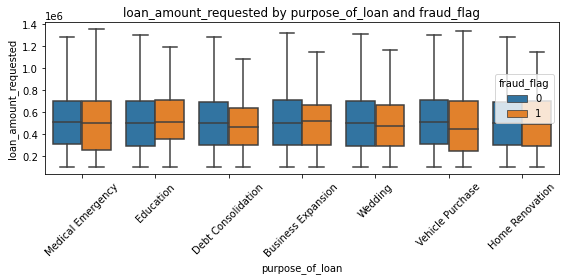

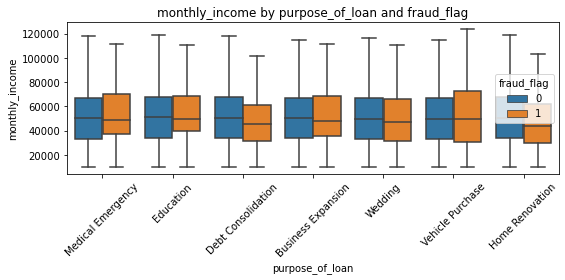

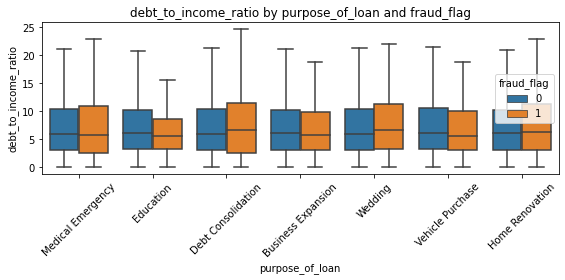

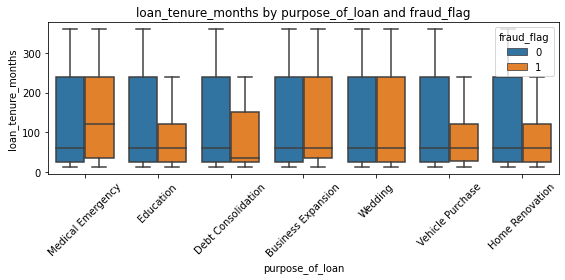

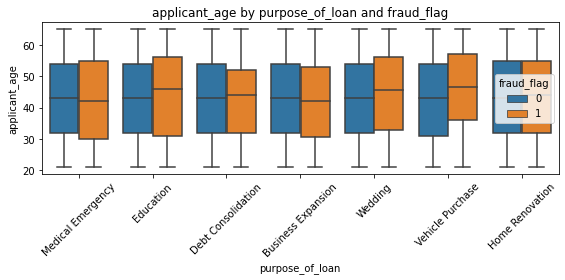

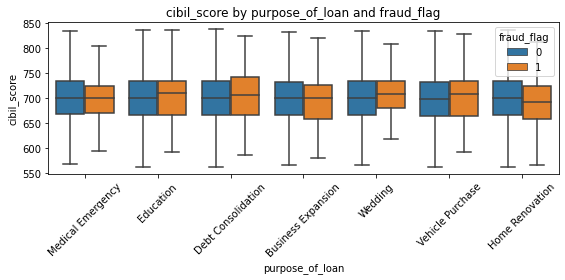

In [45]:
for var in num_vars:
    plt.figure(figsize=(8, 4))
    sns.boxplot(
        data=df,
        x=cat_var,
        y=var,
        hue=target,
        showfliers=False
    )
    plt.xticks(rotation=45)
    plt.title(f"{var} by {cat_var} and fraud_flag")
    plt.tight_layout()
    plt.show()


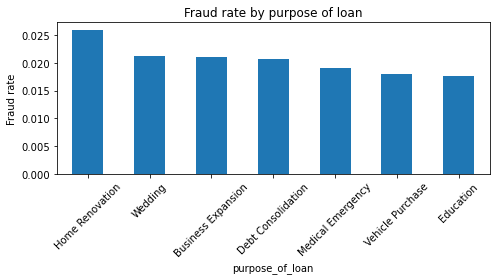

In [46]:
fraud_rate = (
    df
    .groupby(cat_var)[target]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
fraud_rate.plot(kind='bar')
plt.ylabel("Fraud rate")
plt.title("Fraud rate by purpose of loan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Problématique avec isolation forest :
    
Les anomalies frauduleuses ne correspondent pas à des observations isolées dans l’espace des variables, mais à des dossiers dont les caractéristiques sont compatibles avec des profils non frauduleux, ce qui limite l’efficacité des méthodes basées sur l’isolement global.

Les mécanismes de fraude ne sont pas capturables à partir des seules variables financières statiques disponibles.